In [1]:
using Pkg
ENV["JULIA_REVISE_POLL"]="1"
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")

In [2]:
using Revise

In [3]:
using PyPlot, PyCall, Peaks, JJDFTX, LinearAlgebra

┌ Info: Precompiling JJDFTX [0d21db8c-e7cb-497b-98f4-4306b49e2569]
└ @ Base loading.jl:1317


Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [5]:
write_map_write_h("wannier", [12, 12, 1], spin=Val('d'))

In [12]:
hwannier_up = hwannier("wannierUp.txt", "wannierUp.map.txt")
hwannier_dn = hwannier("wannierDn.txt", "wannierDn.map.txt")
cellmap_up = np.loadtxt("wannierUp.map.txt")
cellmap_dn = np.loadtxt("wannierDn.map.txt");

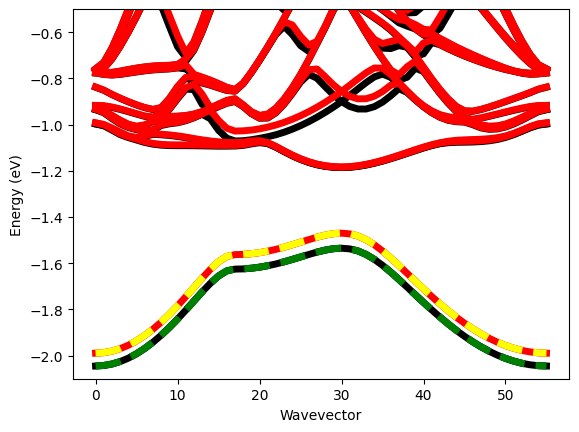

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f77ce1b44c0>

In [20]:
plotwannierbands(hwannier_up, cellmap_up, 1, linewidth=5, linestyle="dashed")
plotwannierbands(hwannier_dn, cellmap_dn, 1, linewidth=5, linestyle="dashed")
plot_bands("Rb-bands-0.313.eigenvals", spin=2, whichbands=[109:130...])
ylim(-2.1, -0.5)
plotwannierbands(hwannier_up, cellmap_up, 1, linewidth=5, linestyle="dashed", color="green")
plotwannierbands(hwannier_dn, cellmap_dn, 1, linewidth=5, linestyle="dashed", color="yellow")


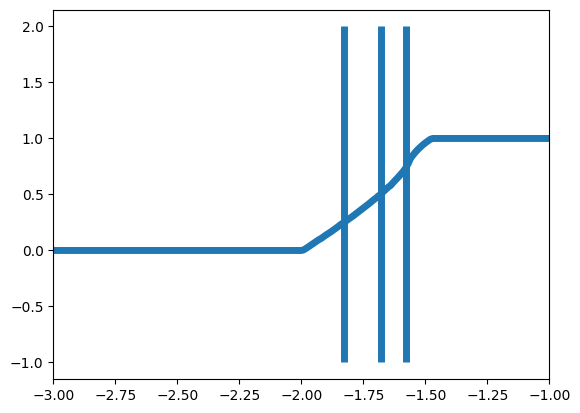

Quarter Filling: -1.83
Half Filling: -1.68
Three Quarters Filling: -1.58


(-3.0, -1.0)

In [41]:
x_up, y_up = find_chemical_potential(hwannier_up, cellmap_up, 1,  offset=3)
x_dn, y_dn = find_chemical_potential(hwannier_dn, cellmap_dn, offset=3)

xlim(-3, -1)

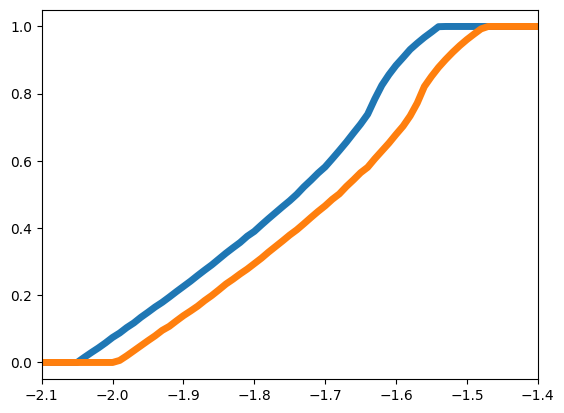

(-2.1, -1.4)

In [46]:
plot(x_up, y_up, linewidth=5)
plot(x_dn, y_dn, linewidth=5)
xlim(-2.1, -1.4)

In [43]:
x[argmin(abs.(y_up+y_dn .- 1))]

-1.71

In [47]:
kpts = bandstructkpoints2q();
lattice_vectors = loadlattice("../Rubidium-82.out")

3-element Vector{Vector{Float64}}:
 [8.7558684774, -2.1665141392400002, 0.0]
 [-6.2541842099, -6.499563584800001, 0.0]
 [0.0, 0.0, 21.16708]

In [50]:
100(abs(cross(lattice_vectors[1], lattice_vectors[2])[3])/(4.727486978767153*4.727486978767153*0.529*0.529*sqrt(3)/2)/13-1)

0.06704974230504757

In [59]:
impols = []

for q in kpts
    up = im_polarization(hwannier_up, cellmap_up, lattice_vectors, q, -1.9;spin=1, mesh=50, histogram_width=30, normalized=true, verbose=true) 
    dn = im_polarization(hwannier_dn, cellmap_dn, lattice_vectors, q, -1.9;spin=1, mesh=50, histogram_width=30, normalized=true, verbose=true) 
    push!(impols, up+dn)
end

[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.029411764706, 0.0, 0.0]
[0.029411764706, 0.0, 0.0]
[0.058823529412, 0.0, 0.0]
[0.058823529412, 0.0, 0.0]
[0.088235294118, 0.0, 0.0]
[0.088235294118, 0.0, 0.0]
[0.117647058824, 0.0, 0.0]
[0.117647058824, 0.0, 0.0]
[0.147058823529, 0.0, 0.0]
[0.147058823529, 0.0, 0.0]
[0.176470588235, 0.0, 0.0]
[0.176470588235, 0.0, 0.0]
[0.205882352941, 0.0, 0.0]
[0.205882352941, 0.0, 0.0]
[0.235294117647, 0.0, 0.0]
[0.235294117647, 0.0, 0.0]
[0.264705882353, 0.0, 0.0]
[0.264705882353, 0.0, 0.0]
[0.294117647059, 0.0, 0.0]
[0.294117647059, 0.0, 0.0]
[0.323529411765, 0.0, 0.0]
[0.323529411765, 0.0, 0.0]
[0.352941176471, 0.0, 0.0]
[0.352941176471, 0.0, 0.0]
[0.382352941176, 0.0, 0.0]
[0.382352941176, 0.0, 0.0]
[0.411764705882, 0.0, 0.0]
[0.411764705882, 0.0, 0.0]
[0.441176470588, 0.0, 0.0]
[0.441176470588, 0.0, 0.0]
[0.470588235294, 0.0, 0.0]
[0.470588235294, 0.0, 0.0]
[0.5, 0.0, 0.0]
[0.5, 0.0, 0.0]
[0.512820512769, -0.025641025385, 0.0]
[0.512820512769, -0.025641025385,

In [78]:
realpols = zeros(56, 100)

for (i, line) in enumerate(readlines("bandstruct.kpoints")[3:end])
    q = parse.(Float64, split(line)[2:4])
    b1 = unnormalize_kvector(lattice_vectors, q)
    screening=exp(-6*sqrt(sum(b1.^2)))
    for (j, omega) in enumerate(range(0.1, 1, length=100))
        eps = return_2d_epsilon(q, lattice_vectors, omega, impols[i], 100, 30)
        realpols[i, j] = real(eps)+2*6*screening/(1+6*(1-screening))
    end
end

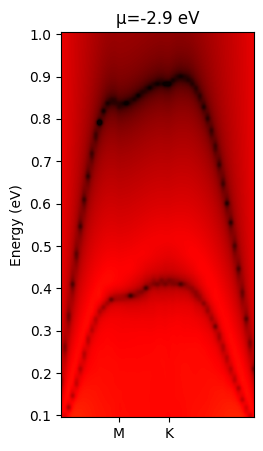

(2.0, 52.0)

In [104]:
energyrange = round.(range(0.1, 1, length=10), digits=3)
energyrange2 = round.(range(0.1, 1, length=100), digits=3)

figure(figsize=(10, 5))
subplot(1, 3, 1)
imshow(transpose(log.(abs.(realpols[:, :])) .+001), interpolation="gaussian", cmap="hot", origin="lower", vmax=15, vmin=-4)
ylabel("Energy (eV)")
yticks(range(0, 99, length=10), energyrange )
xticks([])
title("μ=-2.9 eV")
label_plots()
xlim(2, 52)

In [122]:
realpols_cubature = zeros(56, 100)

for (i, line) in enumerate(readlines("bandstruct.kpoints")[3:10])
    println(i)
    q = parse.(Float64, split(line)[2:4])
    b1 = unnormalize_kvector(lattice_vectors, q)
    screening=exp(-6*sqrt(sum(b1.^2)))
    for (j, omega) in enumerate(range(0.1, 1, length=100))
        eps = direct_epsilon_cubature(hwannier_up, cellmap_up, lattice_vectors, q, omega, -1.9, maxevals=1000)+direct_epsilon_cubature(hwannier_dn, cellmap_dn, lattice_vectors, q, omega, -1.9, maxevals=1000)
        realpols_cubature[i, j] = real(eps)+2*6*screening/(1+6*(1-screening))
    end
end

1
2
3
4
5
6
7
8


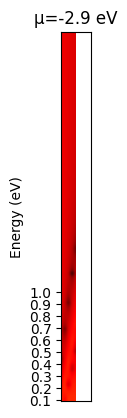

(2.0, 10.0)

In [124]:
imshow(transpose(log.(abs.(realpols_cubature[:, :])) .+001), interpolation="gaussian", cmap="hot", origin="lower", vmax=15, vmin=-4)
ylabel("Energy (eV)")
yticks(range(0, 29, length=10), energyrange )
xticks([])
title("μ=-2.9 eV")
label_plots()

xlim(2, 10)

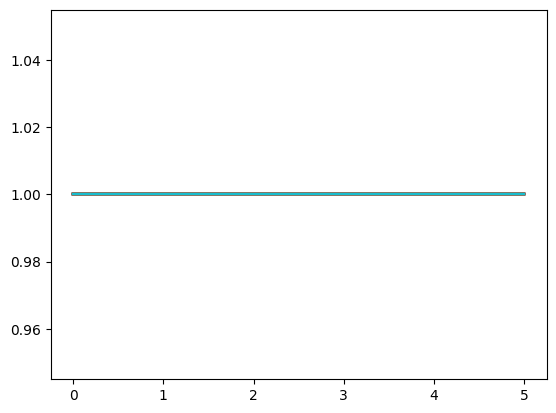

100-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f77ccfd42e0>
 PyObject <matplotlib.lines.Line2D object at 0x7f77ccfd43d0>
 PyObject <matplotlib.lines.Line2D object at 0x7f77ccfd4490>
 PyObject <matplotlib.lines.Line2D object at 0x7f77ccffa910>
 PyObject <matplotlib.lines.Line2D object at 0x7f77ccff1c40>
 PyObject <matplotlib.lines.Line2D object at 0x7f77cce56670>
 PyObject <matplotlib.lines.Line2D object at 0x7f77cce639d0>
 PyObject <matplotlib.lines.Line2D object at 0x7f77cce63a90>
 PyObject <matplotlib.lines.Line2D object at 0x7f77cce63b50>
 PyObject <matplotlib.lines.Line2D object at 0x7f77cce63c10>
 PyObject <matplotlib.lines.Line2D object at 0x7f77ccedb340>
 PyObject <matplotlib.lines.Line2D object at 0x7f77cce63d60>
 PyObject <matplotlib.lines.Line2D object at 0x7f77cce63e20>
 ⋮
 PyObject <matplotlib.lines.Line2D object at 0x7f77c13f5100>
 PyObject <matplotlib.lines.Line2D object at 0x7f77c13f5ee0>
 PyObject <matplotlib.lines.Line2D object at 0x7f77c

In [140]:
plot([argmin.(log.(abs.(realpols_cubature[i, :]))) for i in 2:7] )

In [129]:
realpols_cubature[1, :]

100-element Vector{Float64}:
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
   ⋮
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN